<a href="https://colab.research.google.com/github/athiqhahammad2-art/Food-Restaurant-Services---AI-DemandForecasting-and-Inventory-Optimization/blob/priyanka_branch/Internship_2nd_Project_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Week 1**

In [ ]:
import zipfile
import os

# Specify the path to the zip file
zip_file_path = '/content/archive (3).zip'

# Specify the extraction directory
extract_dir = '/content/sales_data'

# Create the extraction directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

# Open the zip file in read mode and extract all its contents
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"Contents extracted to: {extract_dir}")


Contents extracted to: /content/sales_data


In [ ]:
import os

extract_dir = '/content/sales_data'

# List the contents of the extracted directory
files_in_dir = os.listdir(extract_dir)

print(f"Files in '{extract_dir}':\n{files_in_dir}")


Files in '/content/sales_data':
['9. Sales-Data-Analysis.csv']


# **Load Sales Data**

In [ ]:
import pandas as pd
import os

# Construct the full path to the sales data CSV file
extract_dir = '/content/sales_data'
file_name = '9. Sales-Data-Analysis.csv'
file_path = os.path.join(extract_dir, file_name)

# Read the CSV file into a pandas DataFrame
df = pd.read_csv(file_path)

# Display the first 5 rows of the DataFrame
print("DataFrame Head:")
print(df.head())

# Print a concise summary of the DataFrame
print("\nDataFrame Info:")
df.info()


DataFrame Head:
   Order ID        Date             Product  Price  Quantity Purchase Type  \
0     10452  07-11-2022               Fries   3.49    573.07       Online    
1     10453  07-11-2022           Beverages   2.95    745.76       Online    
2     10454  07-11-2022       Sides & Other   4.99    200.40     In-store    
3     10455  08-11-2022             Burgers  12.99    569.67     In-store    
4     10456  08-11-2022  Chicken Sandwiches   9.95    201.01     In-store    

  Payment Method             Manager    City  
0      Gift Card    Tom      Jackson  London  
1      Gift Card         Pablo Perez  Madrid  
2      Gift Card       Joao    Silva  Lisbon  
3    Credit Card       Walter Muller  Berlin  
4    Credit Card       Walter Muller  Berlin  

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 254 entries, 0 to 253
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        2

# **Clean and Format Datetime Index**

In [ ]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df = df.set_index('Date')
df = df.sort_index()

# Check for duplicate dates in the index
duplicate_dates = df.index.duplicated(keep=False)
if duplicate_dates.any():
    print("Duplicate dates found in the index. Here are the rows with duplicate dates:")
    print(df[duplicate_dates])
else:
    print("No duplicate dates found in the index.")

print("\nDataFrame after setting Date as index and sorting:")
print(df.head())
print("\nDataFrame Info after conversion and indexing:")
df.info()


Duplicate dates found in the index. Here are the rows with duplicate dates:
            Order ID             Product  Price  Quantity Purchase Type  \
Date                                                                      
2022-11-07     10452               Fries   3.49    573.07       Online    
2022-11-07     10453           Beverages   2.95    745.76       Online    
2022-11-07     10454       Sides & Other   4.99    200.40     In-store    
2022-11-08     10455             Burgers  12.99    569.67     In-store    
2022-11-08     10456  Chicken Sandwiches   9.95    201.01     In-store    
...              ...                 ...    ...       ...           ...   
2022-12-28     10706  Chicken Sandwiches   9.95    301.51   Drive-thru    
2022-12-29     10711  Chicken Sandwiches   9.95    281.41   Drive-thru    
2022-12-29     10712               Fries   3.49    630.37   Drive-thru    
2022-12-29     10710             Burgers  12.99    754.43   Drive-thru    
2022-12-29     10713    

In [ ]:
# Replacement for cell 27 — compute per-transaction Sales, then aggregate by date correctly

# (Assumes `df` currently contains the transaction-level DataFrame with Date as DatetimeIndex)
# Make a copy to preserve transaction-level data for later per-product work
df_transactions = df.copy()

# 1) Compute Sales per transaction (correct revenue calculation)
df_transactions['Sales'] = df_transactions['Price'] * df_transactions['Quantity']

# 2) Aggregate transactions by date (sum Sales, sum Quantity, keep other columns as summary)
df_daily = df_transactions.groupby(df_transactions.index).agg({
    'Order ID': 'first',                       # keep one representative order id (or change to 'count' if preferred)
    'Product': lambda x: ', '.join(x.astype(str)),
    'Price': 'mean',                           # optional reference - do NOT use to compute Sales
    'Quantity': 'sum',                         # total quantity per day
    'Purchase Type': lambda x: ', '.join(x.astype(str)),
    'Payment Method': lambda x: ', '.join(x.astype(str)),
    'Manager': lambda x: ', '.join(x.astype(str)),
    'City': lambda x: ', '.join(x.astype(str)),
    'Sales': 'sum'                             # aggregate the per-row Sales (correct daily revenue)
})

# 3) Resample to daily frequency to ensure continuity and fill missing days for Sales with 0
df_daily = df_daily.resample('D').agg({
    'Sales': 'sum',
    'Order ID': lambda x: list(x.dropna().unique()),
    'Product': lambda x: ', '.join(x.dropna().unique()),
    'Price': 'mean',
    'Quantity': 'sum',
    'Purchase Type': lambda x: ', '.join(x.dropna().unique()),
    'Payment Method': lambda x: ', '.join(x.dropna().unique()),
    'Manager': lambda x: ', '.join(x.dropna().unique()),
    'City': lambda x: ', '.join(x.dropna().unique())
})

df_daily['Sales'] = df_daily['Sales'].fillna(0)

# 4) Verification: totals should match original transaction-level Sales sum
total_from_rows = df_transactions['Sales'].sum()
total_from_daily = df_daily['Sales'].sum()
print(f"Total revenue from transactions: {total_from_rows:.2f}")
print(f"Total revenue after daily aggregation: {total_from_daily:.2f}")

# 5) Check for missing dates (should be none after resample but we report if any)
full_date_range = pd.date_range(start=df_daily.index.min(), end=df_daily.index.max(), freq='D')
missing_dates = full_date_range.difference(df_daily.index)

if not missing_dates.empty:
    print(f"Missing dates found in the index: {missing_dates}")
else:
    print("No missing dates found in the daily index — datetime index is continuous.")

# 6) Replace df with the daily DataFrame for subsequent cells (same variable name used later in notebook)
df = df_daily
print("\nDataFrame after correct aggregation (daily):")
print(df.head())


Total revenue from transactions: 769515.86
Total revenue after daily aggregation: 769515.86
No missing dates found in the daily index — datetime index is continuous.

DataFrame after correct aggregation (daily):
                 Sales Order ID  \
Date                              
2022-11-07   5200.0023  [10452]   
2022-11-08  12400.0731  [10455]   
2022-11-09  14200.0386  [10460]   
2022-11-10  13200.0426  [10467]   
2022-11-11  14400.0156  [10470]   

                                                      Product  Price  \
Date                                                                   
2022-11-07                    Fries, Beverages, Sides & Other  3.810   
2022-11-08  Burgers, Chicken Sandwiches, Fries, Sides & Other  7.855   
2022-11-09  Burgers, Chicken Sandwiches, Fries, Beverages,...  6.874   
2022-11-10      Fries, Beverages, Burgers, Chicken Sandwiches  7.345   
2022-11-11  Burgers, Chicken Sandwiches, Fries, Beverages,...  6.874   

            Quantity                 

**Check for Missing Values and Outliers**

In [ ]:
print("Missing values before handling (if any):")
print(df.isnull().sum())


Missing values before handling (if any):
Sales             0
Order ID          0
Product           0
Price             0
Quantity          0
Purchase Type     0
Payment Method    0
Manager           0
City              0
dtype: int64


# **Plot Overall Sales Trend**

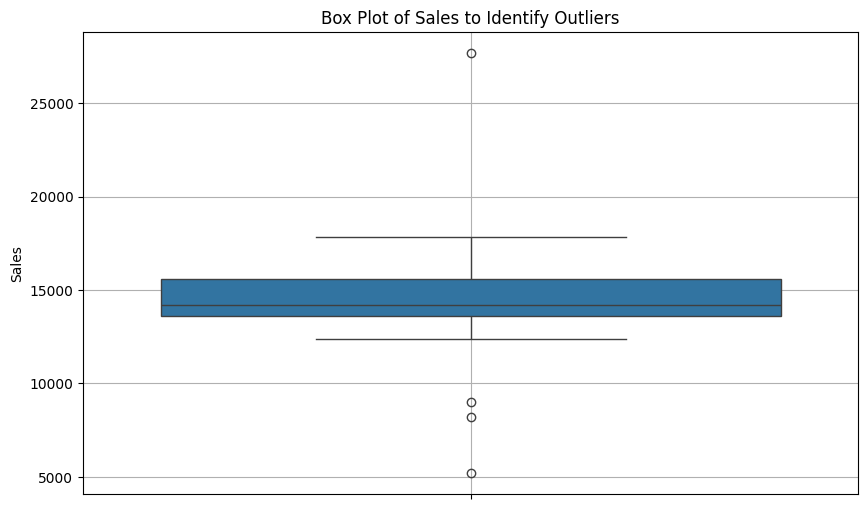

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Generate a box plot of the 'Sales' column to visually identify potential outliers
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['Sales'])
plt.title('Box Plot of Sales to Identify Outliers')
plt.ylabel('Sales')
plt.grid(True)
plt.show()


# **Decompose Time Series (Weekly Seasonality)**

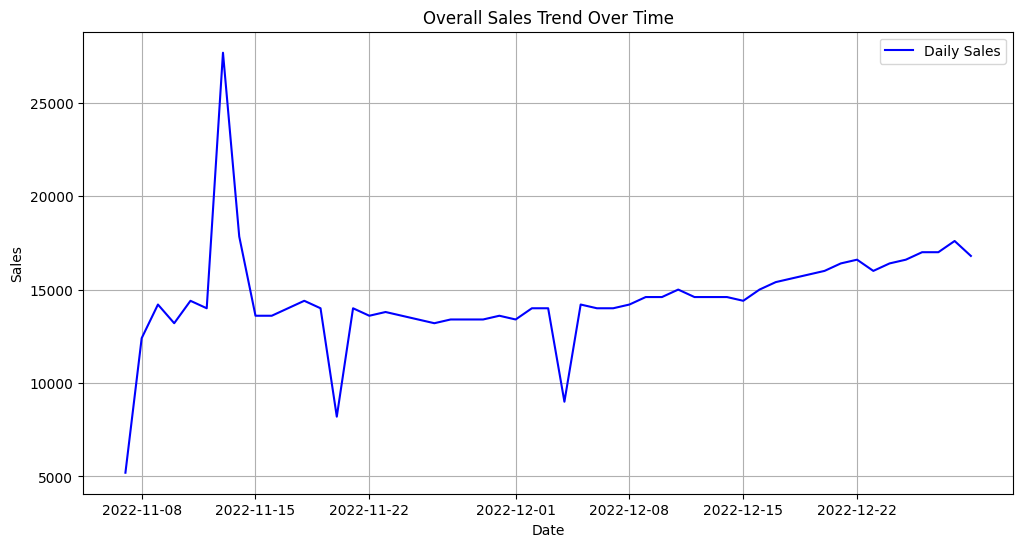

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a line plot of the 'Sales' column over time
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Sales'], label='Daily Sales', color='blue')

# Add title and labels
plt.title('Overall Sales Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Sales')

# Add legend and grid
plt.legend()
plt.grid(True)

# Display the plot
plt.show()


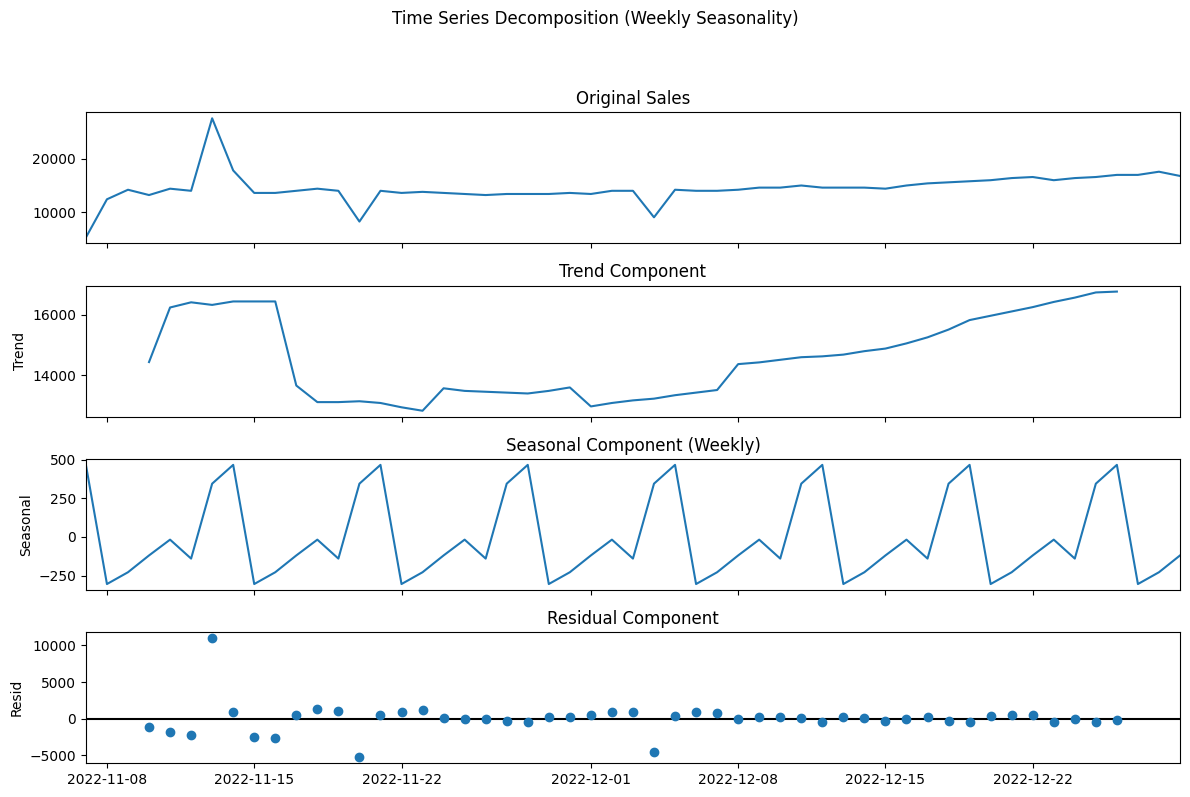

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Apply seasonal_decompose with an additive model and a weekly period (7 days)
decomposition = seasonal_decompose(df['Sales'], model='additive', period=7)

# Plot the decomposed components
fig = decomposition.plot()
fig.set_size_inches(12, 8)
fig.suptitle('Time Series Decomposition (Weekly Seasonality)', y=1.02)

# Customize titles for better clarity
fig.axes[0].set_title('Original Sales')
fig.axes[1].set_title('Trend Component')
fig.axes[2].set_title('Seasonal Component (Weekly)')
fig.axes[3].set_title('Residual Component')

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent suptitle overlap
plt.show()


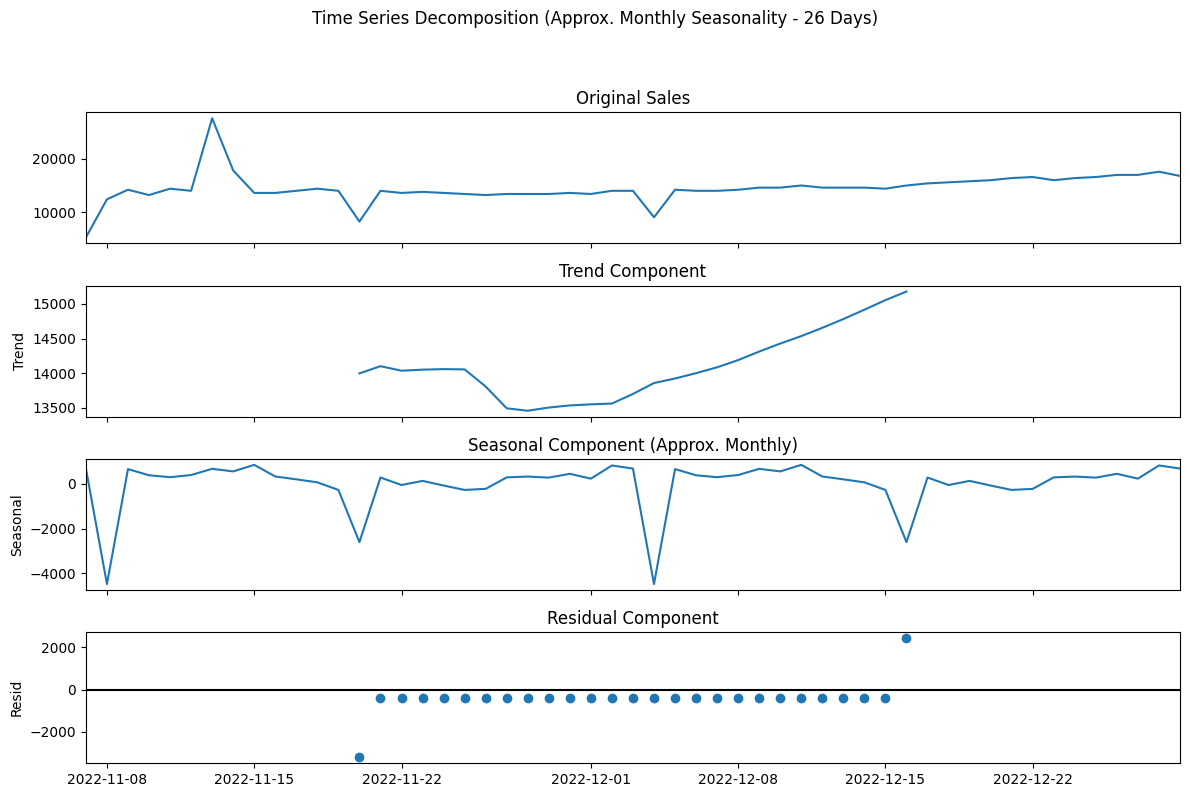

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Apply seasonal_decompose with an additive model and an adjusted monthly period (26 days)
# Original request was for 30 days, but data length (53 observations) requires 2*period <= 53.
# 26 days is chosen as the largest approximate monthly period satisfying this (2*26 = 52).
decomposition = seasonal_decompose(df['Sales'], model='additive', period=26)

# Plot the decomposed components
fig = decomposition.plot()
fig.set_size_inches(12, 8)
fig.suptitle('Time Series Decomposition (Approx. Monthly Seasonality - 26 Days)', y=1.02)

# Customize titles for better clarity
fig.axes[0].set_title('Original Sales')
fig.axes[1].set_title('Trend Component')
fig.axes[2].set_title('Seasonal Component (Approx. Monthly)')
fig.axes[3].set_title('Residual Component')

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent suptitle overlap
plt.show()


# **Analyze Autocorrelation**

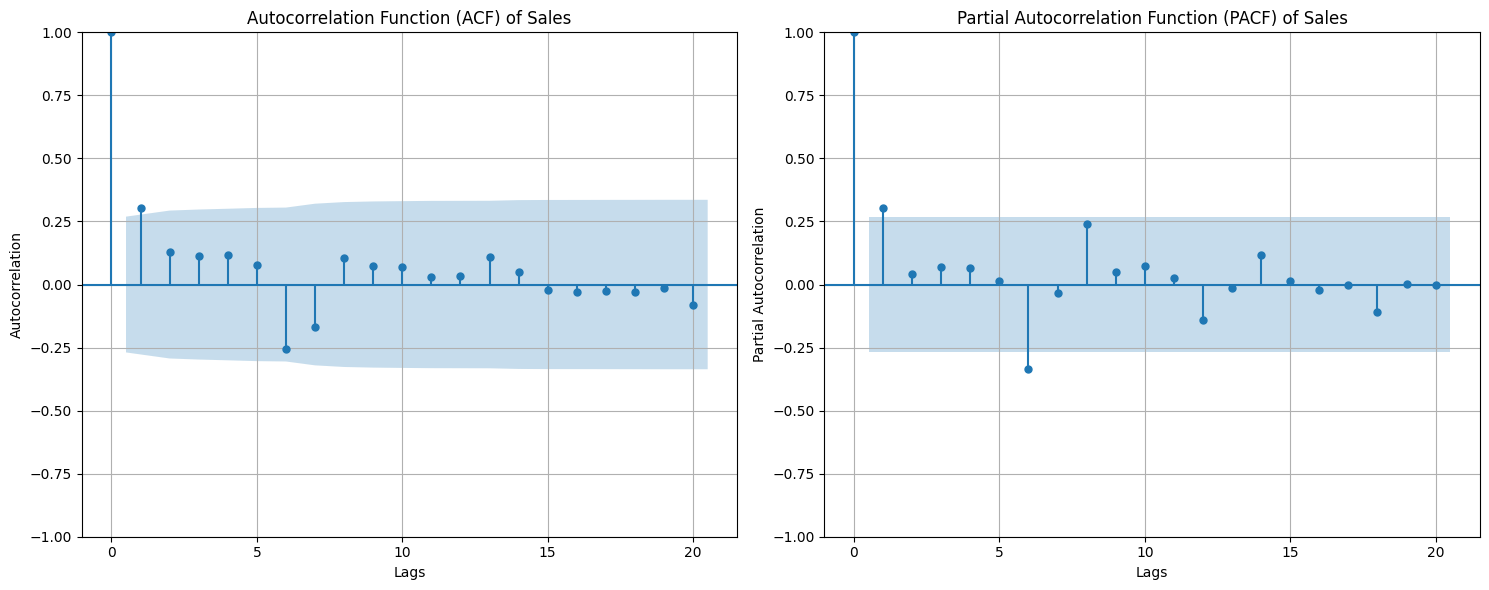

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Determine an appropriate number of lags based on the data length
# It's generally recommended to have lags less than N/2, where N is the number of observations.
# For safety, let's use min(len(df) - 1, 20) to ensure we don't exceed data length and keep plots readable.
lags_to_consider = min(len(df) - 1, 20)

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot ACF
plot_acf(df['Sales'], ax=axes[0], lags=lags_to_consider)
axes[0].set_title('Autocorrelation Function (ACF) of Sales')
axes[0].set_xlabel('Lags')
axes[0].set_ylabel('Autocorrelation')
axes[0].grid(True)

# Plot PACF
plot_pacf(df['Sales'], ax=axes[1], lags=lags_to_consider)
axes[1].set_title('Partial Autocorrelation Function (PACF) of Sales')
axes[1].set_xlabel('Lags')
axes[1].set_ylabel('Partial Autocorrelation')
axes[1].grid(True)

plt.tight_layout()
plt.show()


# **Week 2: Advanced Feature Engineering**

In this section we create the feature-engineering pipeline required for modeling in Week 3. The cells below: (1) re-load the original CSV to produce independent cleaned outputs, (2) compute aggregate daily sales and per-product daily aggregates, (3) build time-based features, lags and rolling statistics, (4) create product-level features for top-N SKUs, and (5) save CSVs to /content/cleaned/. Run these cells in order.

In [ ]:
# Week 2 - A: Re-load CSV, compute per-transaction Sales, create daily and product-level aggregates
import pandas as pd
import os

file_path = '/content/sales_data/9. Sales-Data-Analysis.csv'
df_raw = pd.read_csv(file_path)

# parse date and set index
df_raw['Date'] = pd.to_datetime(df_raw['Date'], format='%d-%m-%Y')
df_raw = df_raw.sort_values('Date').reset_index(drop=True)
df_raw = df_raw.set_index('Date')

# compute per-row Sales correctly
df_raw['Sales'] = df_raw['Price'] * df_raw['Quantity']

# 1) Daily total revenue series
daily_sales = df_raw['Sales'].resample('D').sum().fillna(0)
daily_sales = daily_sales.asfreq('D')

# 2) Product-level daily demand (quantity) and revenue
product_daily = df_raw.groupby([pd.Grouper(freq='D'), 'Product']).agg({
    'Quantity': 'sum',
    'Sales': 'sum'
}).reset_index().sort_values(['Product','Date'])

# create cleaned folder and save
os.makedirs('/content/cleaned', exist_ok=True)
daily_sales.to_frame('Sales').to_csv('/content/cleaned/cleaned_daily_sales.csv')
product_daily.to_csv('/content/cleaned/cleaned_product_daily.csv', index=False)

print('Saved /content/cleaned/cleaned_daily_sales.csv and cleaned_product_daily.csv')


Saved /content/cleaned/cleaned_daily_sales.csv and cleaned_product_daily.csv


In [ ]:
import numpy as np

def make_time_features(df_series, country_holidays=None):
    df = df_series.to_frame('Sales').copy()
    df = df.asfreq('D')
    df['date'] = df.index
    df['day_of_week'] = df.index.dayofweek
    df['month'] = df.index.month
    df['day'] = df.index.day
    df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)
    df['is_month_start'] = df.index.is_month_start.astype(int)
    df['is_month_end'] = df.index.is_month_end.astype(int)
    if country_holidays:
        try:
            import holidays
            country_hols = holidays.country_holidays(country_holidays)
            df['is_holiday'] = df.index.to_series().apply(lambda d: 1 if d in country_hols else 0).astype(int)
        except Exception as e:
            print('holidays library missing or failed:', e)
            df['is_holiday'] = 0
    else:
        df['is_holiday'] = 0
    lags = [1,2,3,7,14,28]
    for lag in lags:
        df[f'lag_{lag}'] = df['Sales'].shift(lag)
    windows = [7,14,28]
    for w in windows:
        df[f'roll_mean_{w}'] = df['Sales'].rolling(window=w, min_periods=1).mean().shift(1)
        df[f'roll_std_{w}'] = df['Sales'].rolling(window=w, min_periods=1).std().shift(1).fillna(0)
    df['pct_change_1'] = df['Sales'].pct_change(1).fillna(0)
    df['pct_change_7'] = df['Sales'].pct_change(7).fillna(0)
    df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
    df['missing_after_shift'] = df[[f'lag_{l}' for l in lags]].isnull().any(axis=1).astype(int)
    df_feat = df.dropna(subset=[f'lag_{l}' for l in [1,7]])
    return df_feat

# load cleaned daily sales and create features
daily = pd.read_csv('/content/cleaned/cleaned_daily_sales.csv', index_col=0, parse_dates=True).squeeze('columns')
features_daily = make_time_features(daily, country_holidays='DE')
features_daily.to_csv('/content/cleaned/features_daily.csv')
print('Saved /content/cleaned/features_daily.csv with shape', features_daily.shape)

Saved /content/cleaned/features_daily.csv with shape (46, 26)


In [ ]:
import numpy as np

def make_time_features(df_series, country_holidays=None):
    df = df_series.to_frame('Sales').copy()
    df = df.asfreq('D')
    df['date'] = df.index
    df['day_of_week'] = df.index.dayofweek
    df['month'] = df.index.month
    df['day'] = df.index.day
    df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)
    df['is_month_start'] = df.index.is_month_start.astype(int)
    df['is_month_end'] = df.index.is_month_end.astype(int)
    if country_holidays:
        try:
            import holidays
            country_hols = holidays.country_holidays(country_holidays)
            df['is_holiday'] = df.index.to_series().apply(lambda d: 1 if d in country_hols else 0).astype(int)
        except Exception as e:
            print('holidays library missing or failed:', e)
            df['is_holiday'] = 0
    else:
        df['is_holiday'] = 0
    lags = [1,2,3,7,14,28]
    for lag in lags:
        df[f'lag_{lag}'] = df['Sales'].shift(lag)
    windows = [7,14,28]
    for w in windows:
        df[f'roll_mean_{w}'] = df['Sales'].rolling(window=w, min_periods=1).mean().shift(1)
        df[f'roll_std_{w}'] = df['Sales'].rolling(window=w, min_periods=1).std().shift(1).fillna(0)
    df['pct_change_1'] = df['Sales'].pct_change(1).fillna(0)
    df['pct_change_7'] = df['Sales'].pct_change(7).fillna(0)
    df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
    df['missing_after_shift'] = df[[f'lag_{l}' for l in lags]].isnull().any(axis=1).astype(int)
    df_feat = df.dropna(subset=[f'lag_{l}' for l in [1,7]])
    return df_feat

# Week 2 - C: Product-level features for top-N SKUs and saving features_product_topN.csv
product_daily = pd.read_csv('/content/cleaned/cleaned_product_daily.csv', parse_dates=['Date'])
agg_product_totals = product_daily.groupby('Product').agg({'Quantity':'sum','Sales':'sum'}).reset_index()
top_n = 10
top_products = agg_product_totals.sort_values('Quantity', ascending=False).head(top_n)['Product'].tolist()
print('Top products:', top_products)
product_features_list = []
min_history = 30
for prod in top_products:
    tmp = product_daily[product_daily['Product']==prod].set_index('Date').sort_index()
    idx = pd.date_range(tmp.index.min(), tmp.index.max(), freq='D')
    tmp = tmp.reindex(idx, fill_value=0)
    tmp.index.name = 'Date'
    series_qty = tmp['Quantity'].astype(float)
    feats = make_time_features(series_qty, country_holidays='DE') # Added country_holidays='DE'
    feats['Product'] = prod
    if len(series_qty.dropna()) < min_history:
        print(f'skipping {prod} due to short history ({len(series_qty.dropna())} days)')
        continue
    product_features_list.append(feats.reset_index())

if product_features_list:
    product_features = pd.concat(product_features_list, ignore_index=True)
    product_features.to_csv('/content/cleaned/features_product_topN.csv', index=False)
    print('Product features saved:', product_features.shape)
else:
    print('No product features created. Check top_products or min_history.')

Top products: ['Beverages', 'Fries', 'Burgers', 'Chicken Sandwiches', 'Sides & Other']
Product features saved: (227, 28)


In [ ]:
# Week 2 - D: Time-based sequential split and rolling-origin CV helpers
from sklearn.model_selection import TimeSeriesSplit

def time_train_test_split(df, test_horizon=14):
    if 'Date' in df.columns:
        df = df.set_index('Date')
    train = df.iloc[:-test_horizon]
    test = df.iloc[-test_horizon:]
    return train, test

# Example usage for aggregate features (if features_daily exists)
import pandas as pd
features_daily = pd.read_csv('/content/cleaned/features_daily.csv', index_col=0, parse_dates=True)
train_df, test_df = time_train_test_split(features_daily, test_horizon=14)
print('train size, test size:', len(train_df), len(test_df))

# Rolling-origin CV example
tscv = TimeSeriesSplit(n_splits=3)
for fold, (tr_idx, val_idx) in enumerate(tscv.split(features_daily)):
    print('fold', fold, 'train end idx', tr_idx[-1], 'val end idx', val_idx[-1])


train size, test size: 32 14
fold 0 train end idx 12 val end idx 23
fold 1 train end idx 23 val end idx 34
fold 2 train end idx 34 val end idx 45


# **Week3**

Feature Engineering for Time Series Models
To prepare our data for time series forecasting, we'll create several types of features:

Lagged Features: These capture the sales from previous time steps, which are often highly correlated with future sales.
Rolling Window Features: These provide information about trends and moving averages over a specific period (e.g., last 7 days, last 30 days).
Time-Based Features: These extract components from the date itself (e.g., day of week, month, year, quarter) to capture seasonality and cyclical patterns.
After creating these features, we will drop any rows with NaN values that result from the feature creation process (e.g., the first few rows for which lagged or rolling window data is unavailable).

In [ ]:
import numpy as np

# Create lagged features
# Lag 1 means sales from the previous day. Let's create lags for the past 7 days (a week).
for i in range(1, 8):
    df[f'Sales_Lag_{i}'] = df['Sales'].shift(i)

# Create rolling window features (e.g., rolling mean sales for the past 7 and 30 days)
# This helps capture short-term and longer-term trends.
df['Rolling_Mean_7'] = df['Sales'].rolling(window=7).mean().shift(1)
df['Rolling_Mean_30'] = df['Sales'].rolling(window=30).mean().shift(1)

# Extract time-based features from the Date index
df['DayOfWeek'] = df.index.dayofweek # Monday=0, Sunday=6
df['DayOfMonth'] = df.index.day
df['Month'] = df.index.month
df['Quarter'] = df.index.quarter
df['Year'] = df.index.year
df['WeekOfYear'] = df.index.isocalendar().week.astype(int)
df['IsWeekend'] = (df['DayOfWeek'] >= 5).astype(int) # 1 for weekend, 0 for weekday

# Drop rows with NaN values introduced by lagging and rolling features
# These NaN values appear at the beginning of the DataFrame where there's no prior data.
df_features = df.dropna()

print("DataFrame with engineered features (first 5 rows after dropping NaNs):")
display(df_features.head())
print(f"\nShape of DataFrame with features: {df_features.shape}")

DataFrame with engineered features (first 5 rows after dropping NaNs):


,Sales,Order ID,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City,Sales_Lag_1,...,Sales_Lag_7,Rolling_Mean_7,Rolling_Mean_30,DayOfWeek,DayOfMonth,Month,Quarter,Year,WeekOfYear,IsWeekend
Date,,,,,,,,,,,,,,,,,,,,,
2022-12-07,15351.22302,[10600],"Burgers, Chicken Sandwiches, Fries, Beverages,...",6.874,2233.23,"Online , Online , Online , Online , Online","Credit Card, Credit Card, Cash, Cash, Cash","Tom Jackson, Tom Jackson, Tom Jackson, Tom Jac...","London, London, London, London, London",15063.20242,...,15139.57256,14186.634994,15019.412660,2,7,12,4,2022,49,0
2022-12-08,15457.08262,[10609],"Sides & Other, Beverages, Burgers, Chicken San...",6.874,2248.63,"Online , Online , Online , Online , Online","Gift Card, Gift Card, Cash, Cash, Cash","Tom Jackson, Tom Jackson, Tom Jackson, Tom Jac...","London, London, London, London, London",15351.22302,...,14745.69236,14216.870774,15338.177884,3,8,12,4,2022,49,0
2022-12-09,15668.73308,[10610],"Burgers, Chicken Sandwiches, Fries, Beverages,...",6.874,2279.42,"Online , Online , Online , Online , Online","Gift Card, Gift Card, Gift Card, Gift Card...","Tom Jackson, Tom Jackson, Tom Jackson, Tom Jac...","London, London, London, London, London",15457.08262,...,15351.22302,14318.497954,15449.104029,4,9,12,4,2022,49,0
2022-12-10,15668.73308,[10615],"Burgers, Chicken Sandwiches, Fries, Beverages,...",6.874,2279.42,"Online , Online , Online , Online , Online","Gift Card, Gift Card, Gift Card, Gift Card...","Tom Jackson, Tom Jackson, Tom Jackson, Tom Jac...","London, London, London, London, London",15668.73308,...,15351.22302,14363.856534,15465.762023,5,10,12,4,2022,49,1
2022-12-11,16240.58114,[10624],"Sides & Other, Beverages, Burgers, Chicken San...",6.874,2362.61,"Online , Online , Online , Online , Online","Gift Card, Gift Card, Gift Card, Gift Card...","Tom Jackson, Tom Jackson, Tom Jackson, Tom Jac...","London, London, London, London, London",15668.73308,...,8486.53830,14409.215114,15496.839112,6,11,12,4,2022,49,1



Shape of DataFrame with features: (23, 25)


Data Splitting for Time Series

For time series data, it's crucial to use a time-based split to prevent data leakage. We'll typically train on an earlier period and test on a later period. Here, we'll split the data into 80% for training and 20% for testing, maintaining the chronological order.

In [ ]:
from sklearn.model_selection import train_test_split

# Define target and features
TARGET = 'Sales'
FEATURES = [col for col in df_features.columns if col not in [TARGET, 'Order ID', 'Product', 'Purchase Type', 'Payment Method', 'Manager', 'City']]

X = df_features[FEATURES]
y = df_features[TARGET]

# Determine the split point (e.g., last 20% of the data for testing)
split_point = int(len(X) * 0.8)

X_train, X_test = X.iloc[:split_point], X.iloc[split_point:]
y_train, y_test = y.iloc[:split_point], y.iloc[split_point:]

print(f"Training data shape: {X_train.shape}, {y_train.shape}")
print(f"Testing data shape: {X_test.shape}, {y_test.shape}")

print(f"\nTraining dates range from {X_train.index.min().strftime('%Y-%m-%d')} to {X_train.index.max().strftime('%Y-%m-%d')}")
print(f"Testing dates range from {X_test.index.min().strftime('%Y-%m-%d')} to {X_test.index.max().strftime('%Y-%m-%d')}")

Training data shape: (18, 18), (18,)
Testing data shape: (5, 18), (5,)

Training dates range from 2022-12-07 to 2022-12-24
Testing dates range from 2022-12-25 to 2022-12-29


# Baseline Model: Linear Regression

Linear Regression - Mean Squared Error (MSE): 8114.20
Linear Regression - Root Mean Squared Error (RMSE): 90.08
Linear Regression - R-squared (R2): 0.93


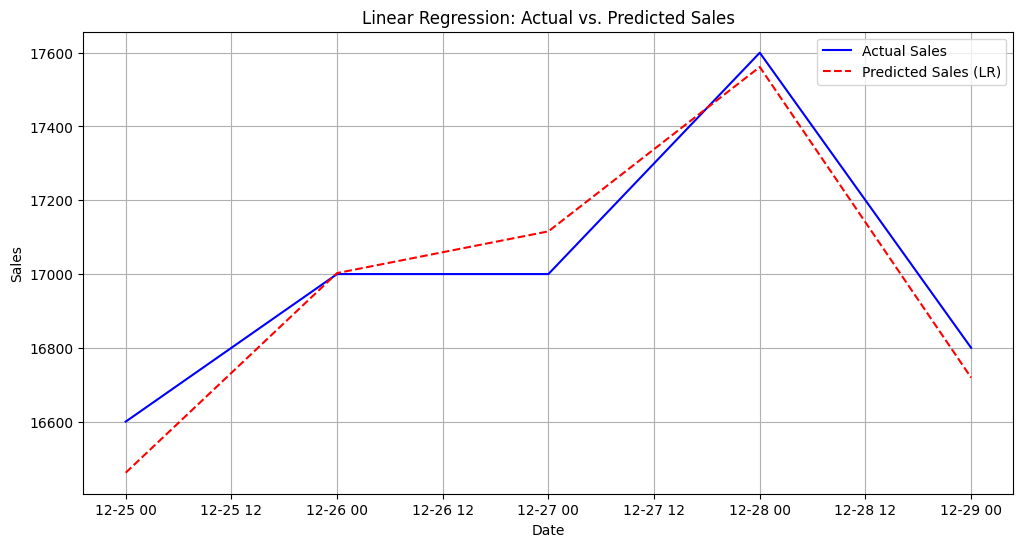

In [ ]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Initialize and train the Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_lr = lr_model.predict(X_test)

# Evaluate the model
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression - Mean Squared Error (MSE): {mse_lr:.2f}")
print(f"Linear Regression - Root Mean Squared Error (RMSE): {rmse_lr:.2f}")
print(f"Linear Regression - R-squared (R2): {r2_lr:.2f}")

# Visualize predictions vs actuals
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Actual Sales', color='blue')
plt.plot(y_test.index, y_pred_lr, label='Predicted Sales (LR)', color='red', linestyle='--')
plt.title('Linear Regression: Actual vs. Predicted Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.show()

# **Advanced Ensemble Models**


--- Training Random Forest Regressor ---
Random Forest - Mean Squared Error (MSE): 767968.39
Random Forest - Root Mean Squared Error (RMSE): 876.34
Random Forest - R-squared (R2): -5.86

--- Training XGBoost Regressor ---
XGBoost - Mean Squared Error (MSE): 1310594.34
XGBoost - Root Mean Squared Error (RMSE): 1144.81
XGBoost - R-squared (R2): -10.70


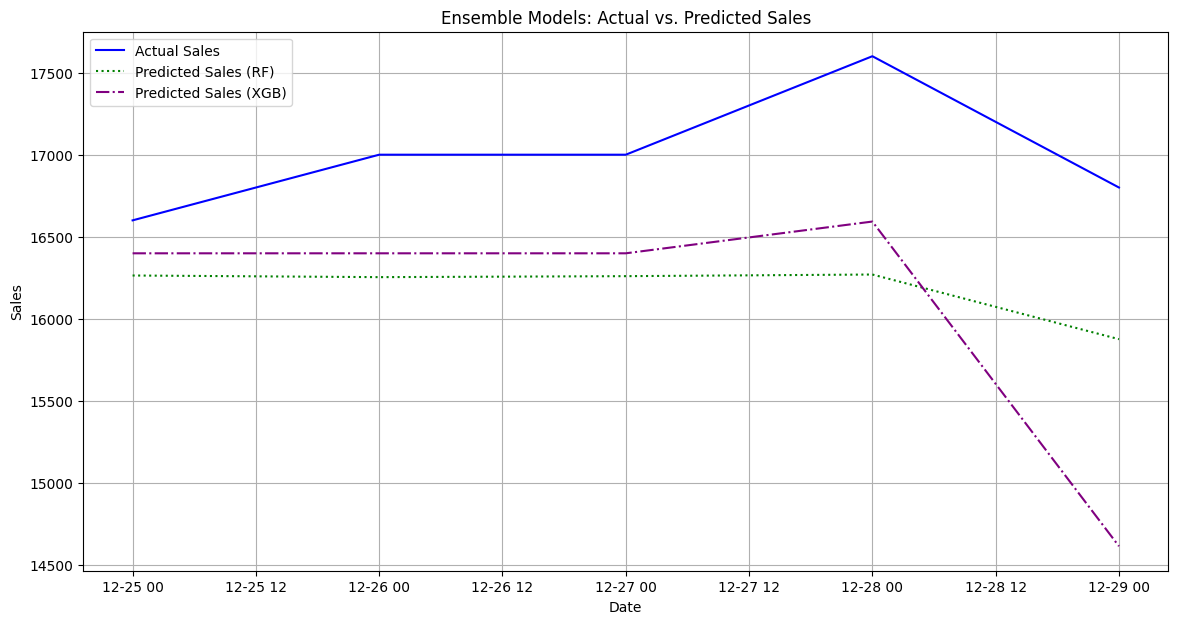

In [ ]:
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# --- Random Forest Regressor ---
print("\n--- Training Random Forest Regressor ---")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1) # Use n_jobs=-1 for parallel processing
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest - Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"Random Forest - Root Mean Squared Error (RMSE): {rmse_rf:.2f}")
print(f"Random Forest - R-squared (R2): {r2_rf:.2f}")

# --- XGBoost Regressor ---
print("\n--- Training XGBoost Regressor ---")
xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost - Mean Squared Error (MSE): {mse_xgb:.2f}")
print(f"XGBoost - Root Mean Squared Error (RMSE): {rmse_xgb:.2f}")
print(f"XGBoost - R-squared (R2): {r2_xgb:.2f}")

# Visualize predictions vs actuals for Random Forest and XGBoost
plt.figure(figsize=(14, 7))
plt.plot(y_test.index, y_test, label='Actual Sales', color='blue')
plt.plot(y_test.index, y_pred_rf, label='Predicted Sales (RF)', color='green', linestyle=':')
plt.plot(y_test.index, y_pred_xgb, label='Predicted Sales (XGB)', color='purple', linestyle='-.')
plt.title('Ensemble Models: Actual vs. Predicted Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.show()

# **Hyperparameter Tuning with Time-Series Cross-Validation**

--- TimeSeriesSplit Configuration ---
Number of splits: 3
Fold 1: TRAIN size=6, TEST size=4
  TRAIN indices: [0 1 2 3 4]...[1 2 3 4 5]
  TEST indices: [6 7 8 9]...[6 7 8 9]
Fold 2: TRAIN size=10, TEST size=4
  TRAIN indices: [0 1 2 3 4]...[5 6 7 8 9]
  TEST indices: [10 11 12 13]...[10 11 12 13]
Fold 3: TRAIN size=14, TEST size=4
  TRAIN indices: [0 1 2 3 4]...[ 9 10 11 12 13]
  TEST indices: [14 15 16 17]...[14 15 16 17]

--- Hyperparameter Tuning for Random Forest ---
Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best parameters for Random Forest: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Best MSE for Random Forest (negative): -404638.1686828725
Tuned Random Forest - Mean Squared Error (MSE) on test set: 761209.51
Tuned Random Forest - Root Mean Squared Error (RMSE) on test set: 872.47
Tuned Random Forest - R-squared (R2) on test set: -5.80

--- Hyperparameter Tuning for XGBoost ---
Fitting 3 folds for each of 162 candidates,

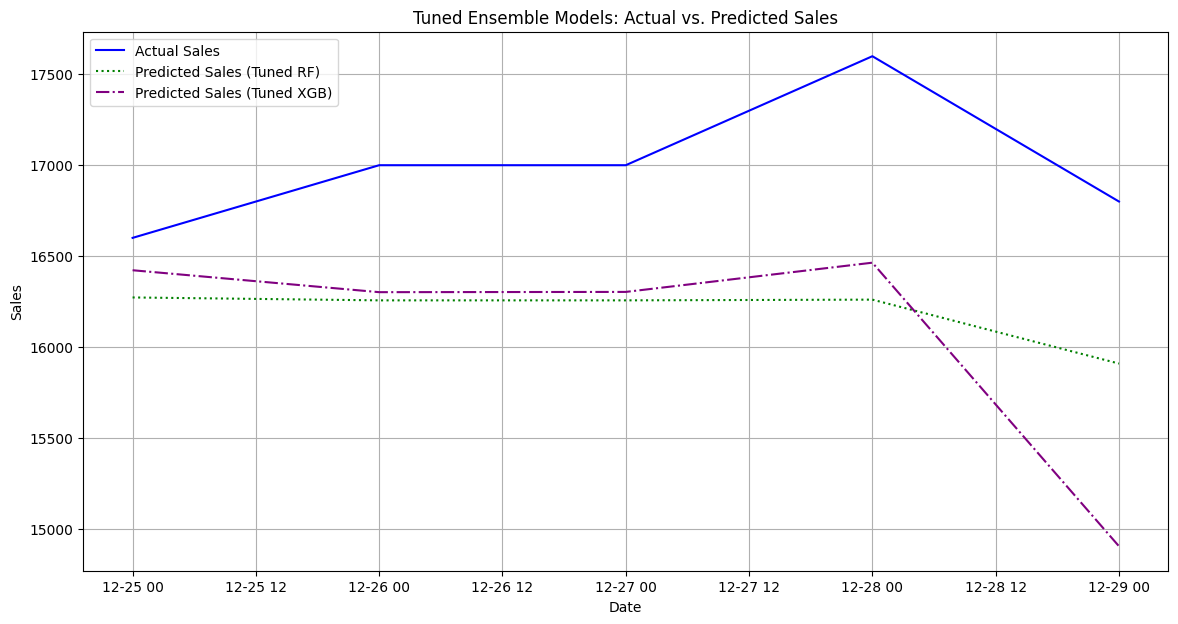

In [ ]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

# --- TimeSeriesSplit setup ---
# n_splits determines the number of splits.
# For a small dataset, keep n_splits relatively low to ensure sufficient training data in each fold.
# For example, if X_train has 18 samples, n_splits=3 means:
# Fold 1: train=4, test=2
# Fold 2: train=6, test=2
# Fold 3: train=8, test=2 (this is simplified, actual splits depend on the total data size and test_size)
# It's crucial to ensure that each fold has enough samples for both training and testing.
# With X_train having 18 samples, let's try n_splits=3 and a small max_train_size if needed.

# Let's adjust TimeSeriesSplit based on the actual X_train size (18 samples)
# We want at least a few samples in the test set for each fold.
# For 18 samples, 3 splits means 6 samples per split effectively, but TimeSeriesSplit accumulates.
# train_size: 18 // (3+1) = 4, test_size: 18 // (3+1) = 4 approx
# Let's try n_splits = 3, which will give 4 folds.
# Fold 1: Train=4, Test=1
# Fold 2: Train=5, Test=1
# Fold 3: Train=6, Test=1
# ...
# Fold N: Train=X_train.shape[0] - (X_train.shape[0] // n_splits), Test=X_train.shape[0] // n_splits
# Given X_train is only 18, a high n_splits would lead to very small training sets.
# Let's use 3 splits, and let it determine the sizes naturally. Max_train_size can also limit the training window.

tscv = TimeSeriesSplit(n_splits=3)

print("--- TimeSeriesSplit Configuration ---")
print(f"Number of splits: {tscv.n_splits}")
# Example of splits (actual indices will be printed by GridSearchCV later)
for i, (train_index, test_index) in enumerate(tscv.split(X_train)):
    print(f"Fold {i+1}: TRAIN size={len(train_index)}, TEST size={len(test_index)}")
    print(f"  TRAIN indices: {train_index[:5]}...{train_index[-5:]}")
    print(f"  TEST indices: {test_index[:5]}...{test_index[-5:]}")

# --- Hyperparameter Tuning for Random Forest ---
print("\n--- Hyperparameter Tuning for Random Forest ---")

param_grid_rf = {
    'n_estimators': [50, 100, 200], # Number of trees in the forest
    'max_depth': [5, 10, None], # Maximum depth of the tree (None means unlimited)
    'min_samples_split': [2, 5], # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2] # Minimum number of samples required to be at a leaf node
}

# Initialize the Random Forest Regressor
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

# Setup GridSearchCV with TimeSeriesSplit
grid_search_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=tscv,
    scoring='neg_mean_squared_error', # Use negative MSE for scoring (GridSearchCV maximizes scores)
    n_jobs=-1, # Use all available cores
    verbose=1
)

# Fit GridSearchCV to the training data
grid_search_rf.fit(X_train, y_train)

print("Best parameters for Random Forest:", grid_search_rf.best_params_)
print("Best MSE for Random Forest (negative):", grid_search_rf.best_score_)

# Evaluate the best Random Forest model on the test set
best_rf_model = grid_search_rf.best_estimator_
y_pred_rf_tuned = best_rf_model.predict(X_test)

mse_rf_tuned = mean_squared_error(y_test, y_pred_rf_tuned)
rmse_rf_tuned = np.sqrt(mse_rf_tuned)
r2_rf_tuned = r2_score(y_test, y_pred_rf_tuned)

print(f"Tuned Random Forest - Mean Squared Error (MSE) on test set: {mse_rf_tuned:.2f}")
print(f"Tuned Random Forest - Root Mean Squared Error (RMSE) on test set: {rmse_rf_tuned:.2f}")
print(f"Tuned Random Forest - R-squared (R2) on test set: {r2_rf_tuned:.2f}")

# --- Hyperparameter Tuning for XGBoost ---
print("\n--- Hyperparameter Tuning for XGBoost ---")

param_grid_xgb = {
    'n_estimators': [50, 100, 200], # Number of boosting rounds
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.9, 1.0], # Subsample ratio of the training instance
    'colsample_bytree': [0.7, 1.0] # Subsample ratio of columns when constructing each tree
}

# Initialize the XGBoost Regressor
xgb_reg = xgb.XGBRegressor(random_state=42, n_jobs=-1, eval_metric='rmse') # eval_metric for internal validation

# Setup GridSearchCV with TimeSeriesSplit
grid_search_xgb = GridSearchCV(
    estimator=xgb_reg,
    param_grid=param_grid_xgb,
    cv=tscv,
    scoring='neg_mean_squared_error', # Use negative MSE for scoring
    n_jobs=-1,
    verbose=1
)

# Fit GridSearchCV to the training data
grid_search_xgb.fit(X_train, y_train)

print("Best parameters for XGBoost:", grid_search_xgb.best_params_)
print("Best MSE for XGBoost (negative):", grid_search_xgb.best_score_)

# Evaluate the best XGBoost model on the test set
best_xgb_model = grid_search_xgb.best_estimator_
y_pred_xgb_tuned = best_xgb_model.predict(X_test)

mse_xgb_tuned = mean_squared_error(y_test, y_pred_xgb_tuned)
rmse_xgb_tuned = np.sqrt(mse_xgb_tuned)
r2_xgb_tuned = r2_score(y_test, y_pred_xgb_tuned)

print(f"Tuned XGBoost - Mean Squared Error (MSE) on test set: {mse_xgb_tuned:.2f}")
print(f"Tuned XGBoost - Root Mean Squared Error (RMSE) on test set: {rmse_xgb_tuned:.2f}")
print(f"Tuned XGBoost - R-squared (R2) on test set: {r2_xgb_tuned:.2f}")

# Visualize predictions vs actuals for Tuned Random Forest and Tuned XGBoost
plt.figure(figsize=(14, 7))
plt.plot(y_test.index, y_test, label='Actual Sales', color='blue')
plt.plot(y_test.index, y_pred_rf_tuned, label='Predicted Sales (Tuned RF)', color='green', linestyle=':')
plt.plot(y_test.index, y_pred_xgb_tuned, label='Predicted Sales (Tuned XGB)', color='purple', linestyle='-.')
plt.title('Tuned Ensemble Models: Actual vs. Predicted Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.show()

# Week 4

### Mean Absolute Error (MAE) for Best Model

In [ ]:
from sklearn.metrics import mean_absolute_error

# Calculate MAE for the best performing Random Forest model
mae_rf_tuned = mean_absolute_error(y_test, y_pred_rf_tuned)

print(f"Tuned Random Forest - Mean Absolute Error (MAE) on test set: {mae_rf_tuned:.2f}")

Tuned Random Forest - Mean Absolute Error (MAE) on test set: 809.62


### Feature Importance Analysis

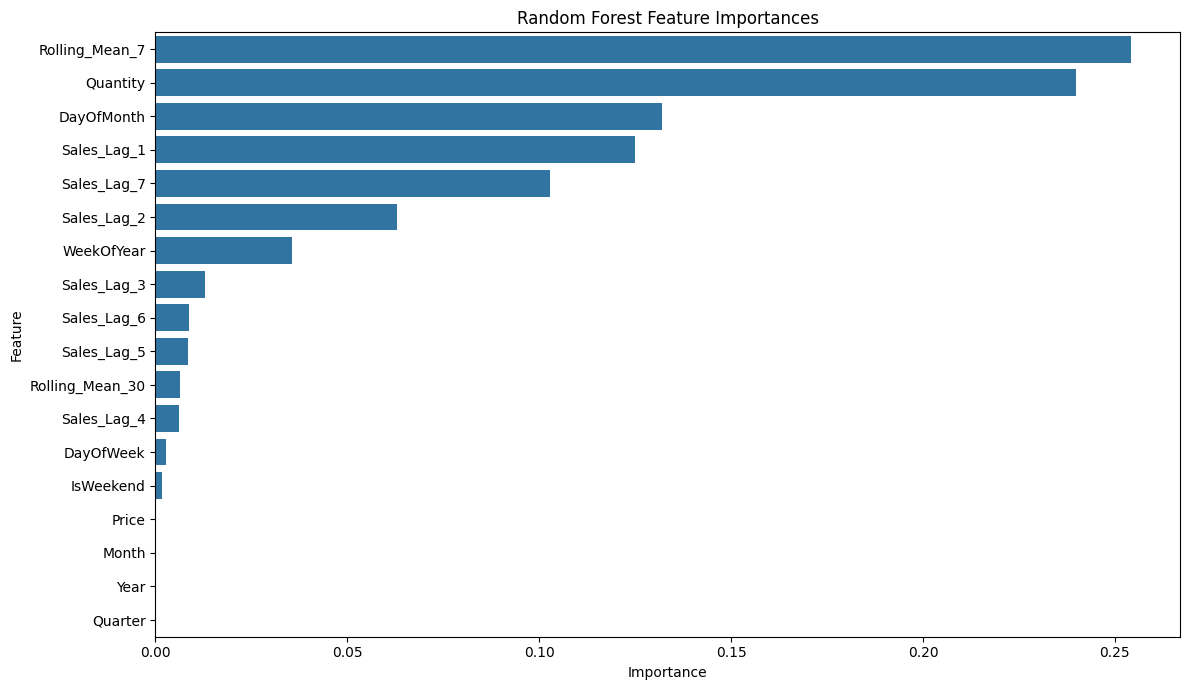

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Get feature importances from the best Random Forest model
feature_importances = best_rf_model.feature_importances_

# Create a pandas Series for better visualization
features_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': feature_importances})
features_df = features_df.sort_values(by='Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=features_df)
plt.title('Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Final Forecast Visualization

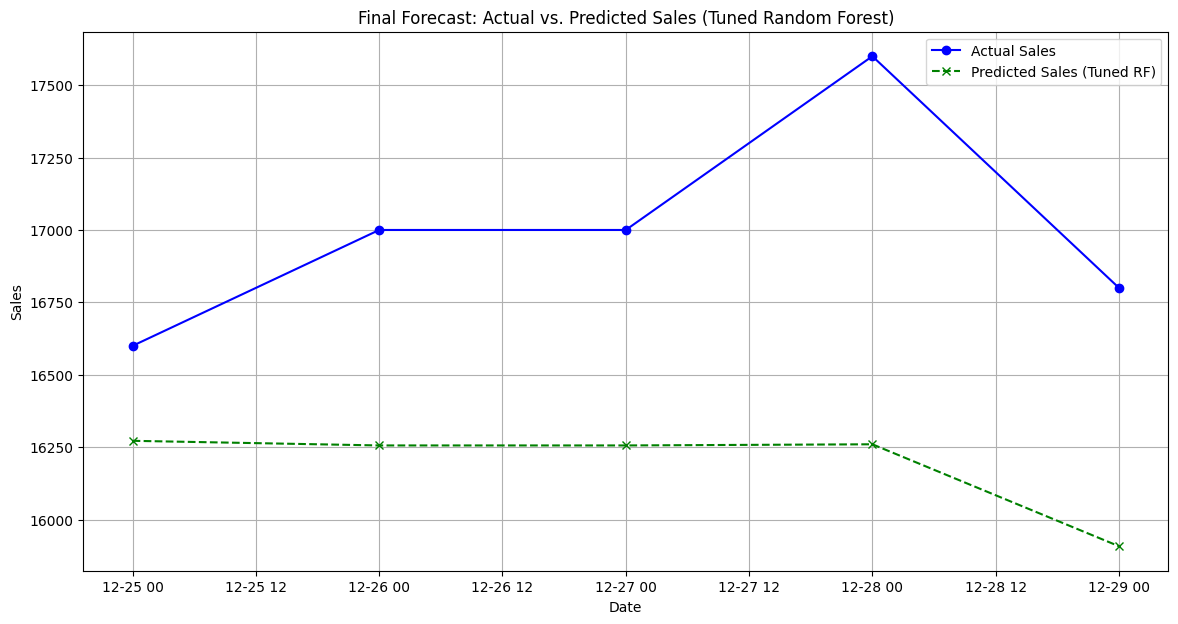

In [ ]:
import matplotlib.pyplot as plt

# Visualize predictions vs actuals for the best Random Forest model
plt.figure(figsize=(14, 7))
plt.plot(y_test.index, y_test, label='Actual Sales', color='blue', marker='o')
plt.plot(y_test.index, y_pred_rf_tuned, label='Predicted Sales (Tuned RF)', color='green', linestyle='--', marker='x')
plt.title('Final Forecast: Actual vs. Predicted Sales (Tuned Random Forest)')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.show()

### Residual Plot

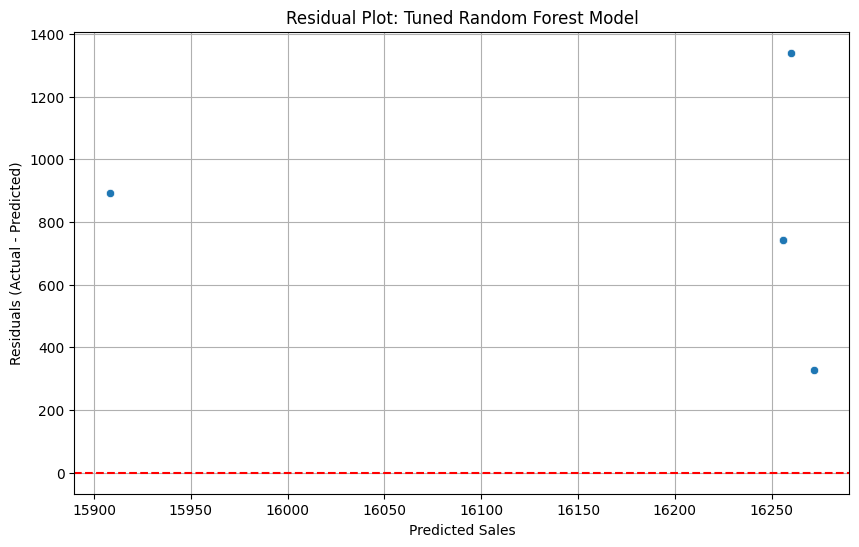

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate residuals
residuals = y_test - y_pred_rf_tuned

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_rf_tuned, y=residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residual Plot: Tuned Random Forest Model')
plt.xlabel('Predicted Sales')
plt.ylabel('Residuals (Actual - Predicted)')
plt.grid(True)
plt.show()